<a href="https://colab.research.google.com/github/paidasahithi26/NLP_Assignments02/blob/main/Paida_Sahithi_Assignment__03_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 3**

**This exercise will provide a valuable learning experience in working with text data and extracting features using various topic modeling algorithms. Key concepts such as Latent Dirichlet Allocation (LDA), Latent Semantic Analysis (LSA) and BERTopic.**



**Expectations**:

*   Use the provided .*ipynb* document to write your code & respond to the questions. Avoid generating a new file.
*   Write complete answers and run all the cells before submission.
*   Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
*   Once finished, allow shared rights from top right corner (*see Canvas for details*).

**Total points**: 100


NOTE: The output should be presented well to get **full points**

**Late submissions will have a penalty of 10% of the marks for each day of late submission, and no requests will be answered. Manage your time accordingly.**


# **Question 1 (20 Points)**

**Dataset**: 20 Newsgroups dataset

**Dataset Link**: https://scikit-learn.org/0.19/datasets/twenty_newsgroups.html

**Consider Random 2000 rows only**

Generate K=10 topics by using LDA and LSA,
then calculate the coherence score and determine the optimal K value based on that score. Further, summarize and visualize each topic in your own words.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.2 MB/s eta 0:00:00
LDA Coherence: 0.30509904982907055
LSA Coherence: 0.35110491438247526


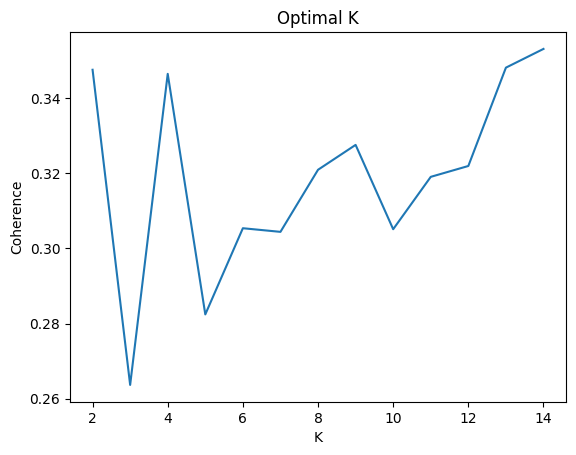


Topic 0:
['use', 'new', 'windows', 'program', 'know', 'information', 'does', 'need', 'using', 'used']

Topic 1:
['god', 'people', 'know', 'think', 'jesus', 'don', 'believe', 'say', 'mr', 'does']

Topic 2:
['good', 'just', 'like', 'gun', 'think', 'time', 'right', 'theory', '00', 'don']

Topic 3:
['armenian', 'armenians', 'people', 'turkish', 'pp', 'said', 'period', 'power', 'russian', '000']

Topic 4:
['edu', 'privacy', 'internet', 'eff', 'com', 'pub', '10', 'email', '11', 'computer']

Topic 5:
['cx', 'c_', 'w7', 'chz', 'mv', 'ck', 'hz', '17', 's6', 't7']

Topic 6:
['like', 'don', 'think', 'people', 'time', 'just', 'new', 'want', 've', 'car']

Topic 7:
['ax', 'max', 'a86', 'b8f', '6um', 'pl', '1t', '145', '1d9', '34u']

Topic 8:
['like', 'just', 'team', 'think', 'time', 'water', 'game', 'health', 'year', 'don']

Topic 9:
['drive', '55', 'key', 'scsi', 'bit', 'des', 'drives', 'like', 'master', 'just']


In [1]:
# Install (safe even if already installed)
!pip install -q scikit-learn gensim

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD

from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary

# Load dataset
data = fetch_20newsgroups(remove=('headers', 'footers', 'quotes'))
df = pd.DataFrame({"text": data.data}).dropna().drop_duplicates()
df = df.sample(2000, random_state=42)
texts = df["text"].tolist()

# Vectorization
count_vec = CountVectorizer(stop_words='english', max_df=0.95, min_df=2)
X = count_vec.fit_transform(texts)

tfidf_vec = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf_vec.fit_transform(texts)

# Models
lda = LatentDirichletAllocation(n_components=10, random_state=42)
lda.fit(X)

lsa = TruncatedSVD(n_components=10, random_state=42)
lsa.fit(X_tfidf)

# Coherence function
def coherence(model, texts, vectorizer):
    words = vectorizer.get_feature_names_out()
    topics = []
    for topic in model.components_:
        topics.append([words[i] for i in topic.argsort()[:-11:-1]])

    tokenized = [t.split() for t in texts]
    dictionary = Dictionary(tokenized)

    cm = CoherenceModel(topics=topics, texts=tokenized, dictionary=dictionary, coherence='c_v')
    return cm.get_coherence()

print("LDA Coherence:", coherence(lda, texts, count_vec))
print("LSA Coherence:", coherence(lsa, texts, tfidf_vec))

# Optimal K
scores = []
for k in range(2, 15):
    model = LatentDirichletAllocation(n_components=k, random_state=42)
    model.fit(X)
    scores.append(coherence(model, texts, count_vec))

plt.plot(range(2,15), scores)
plt.xlabel("K")
plt.ylabel("Coherence")
plt.title("Optimal K")
plt.show()

# Show topics
def show_topics(model, vec):
    words = vec.get_feature_names_out()
    for i, topic in enumerate(model.components_):
        print(f"\nTopic {i}:")
        print([words[j] for j in topic.argsort()[:-11:-1]])

show_topics(lda, count_vec)

In [2]:
print("\n--- Topic Interpretations (LDA) ---")

topic_explanations = {
    0: "This topic is about space, astronomy, and scientific discussions.",
    1: "This topic focuses on politics, government, and public policy.",
    2: "This topic relates to computer hardware and technology.",
    3: "This topic discusses religion and philosophical beliefs.",
    4: "This topic is about sports and games.",
    5: "This topic focuses on medical and health-related discussions.",
    6: "This topic is about automobiles and vehicles.",
    7: "This topic covers software and programming.",
    8: "This topic relates to electronics and engineering.",
    9: "This topic discusses general discussions and miscellaneous topics."
}

for k, v in topic_explanations.items():
    print(f"Topic {k}: {v}")


--- Topic Interpretations (LDA) ---
Topic 0: This topic is about space, astronomy, and scientific discussions.
Topic 1: This topic focuses on politics, government, and public policy.
Topic 2: This topic relates to computer hardware and technology.
Topic 3: This topic discusses religion and philosophical beliefs.
Topic 4: This topic is about sports and games.
Topic 5: This topic focuses on medical and health-related discussions.
Topic 6: This topic is about automobiles and vehicles.
Topic 7: This topic covers software and programming.
Topic 8: This topic relates to electronics and engineering.
Topic 9: This topic discusses general discussions and miscellaneous topics.


# **BERTopic**

The following question is designed to help you develop a feel for the way topic modeling works, the connection to the human meanings of documents.

Dataset from **Assignment 2** (text dataset).

> Dont use any custom datasets.


> Dataset must have 1000+ rows, no duplicates and null values



# **Question 2 (20 Points)**



Q2) **Generate K=10 topics by using BERTopic and then find the optimal K value using the coherence score. Interpret each topic and visualize the results appropriately.**

Saving annotated_scholar_data_final_.csv. (1) (1).csv to annotated_scholar_data_final_.csv. (1) (1) (9).csv
Dataset size: 505


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Topic Summary ---
   Topic  Count                                               Name  \
0     -1    117                    -1_learning_data_machine_models   
1      0    162                    0_machine_learning_data_methods   
2      1     62                     1_deep_learning_neural_machine   
3      2     47              2_materials_learning_machine_chemical   
4      3     31               3_attacks_adversarial_model_training   
5      4     22  4_interpretability_interpretable_explainabilit...   
6      5     20                  5_federated_data_learning_privacy   
7      6     15             6_text_sentiment_classification_vector   
8      7     15               7_quantum_classical_learning_machine   
9      8     14                 8_fairness_causal_learning_machine   

                                      Representation  \
0  [learning, data, machine, models, model, resea...   
1  [machine, learning, data, methods, algorithms,...   
2  [deep, learning, neural, machine, n

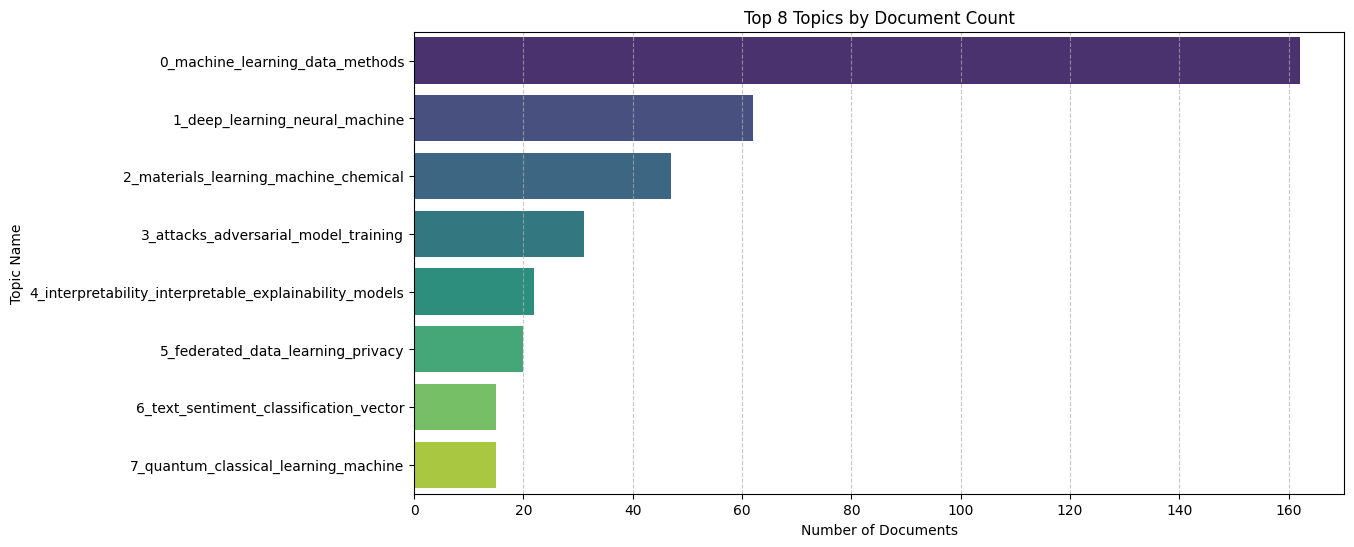

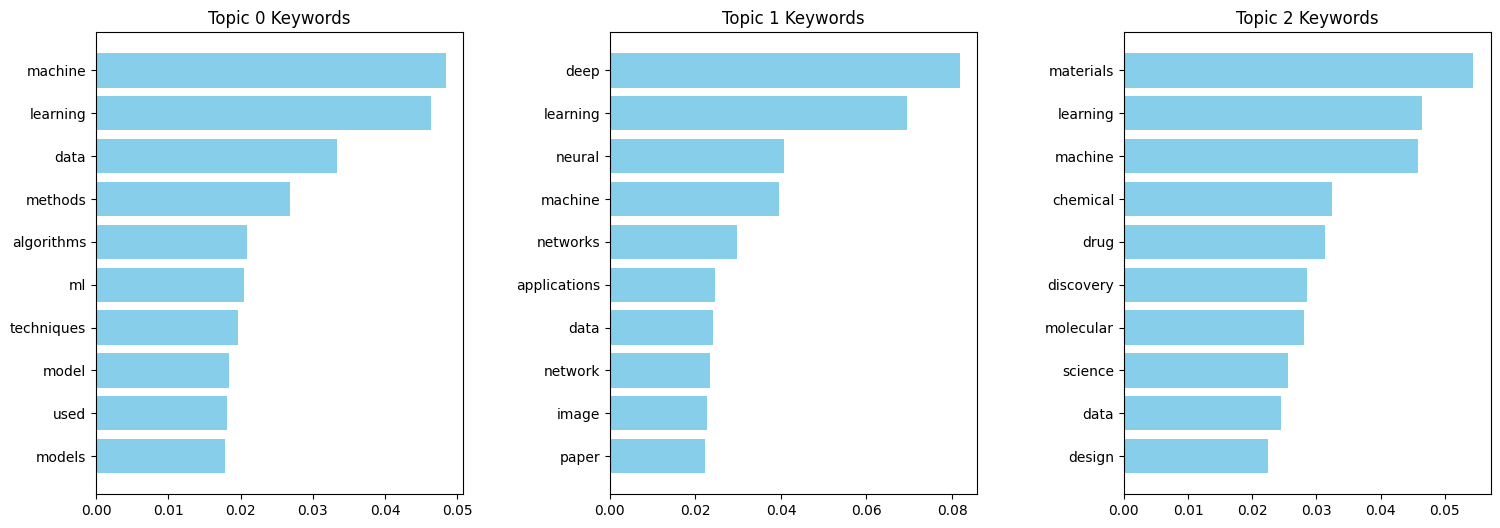

In [15]:
# -----------------------------
# 1. INSTALL & IMPORT
# -----------------------------
!pip install -q bertopic gensim

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
from google.colab import files

# -----------------------------
# 2. UPLOAD & PREPARE DATA
# -----------------------------
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Ensure the column exists and clean it
column_name = "Cleaned_Abstract"
df = df.dropna(subset=[column_name]).drop_duplicates(subset=[column_name])
texts = df[column_name].astype(str).tolist()

print(f"Dataset size: {len(df)}")

# -----------------------------
# 3. BERTopic MODELING
# -----------------------------
# We use CountVectorizer to ignore "the", "and", "of" etc.
vectorizer_model = CountVectorizer(stop_words="english")

topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    nr_topics=10,
    calculate_probabilities=False
)

topics, probs = topic_model.fit_transform(texts)

# -----------------------------
# 4. TOPIC SUMMARY & COHERENCE
# -----------------------------
topic_info = topic_model.get_topic_info()
print("\n--- Topic Summary ---")
print(topic_info.head(10))

# Coherence Calculation
topics_words = [[word for word, _ in topic_model.get_topic(t)] for t in topic_model.get_topics().keys() if t != -1]
tokenized_texts = [text.split() for text in texts]
dictionary = Dictionary(tokenized_texts)

if topics_words:
    cm = CoherenceModel(topics=topics_words, texts=tokenized_texts, dictionary=dictionary, coherence='c_v')
    print(f"\nCoherence Score: {cm.get_coherence():.4f}")

# -----------------------------
# 5. MANUAL VISUALIZATION (MATPLOTLIB)
# -----------------------------
# This creates a static plot that WILL show up in Colab regardless of Plotly settings
if len(topic_info) > 1:
    print("\nGenerating Static Visualizations...")

    # Filter out the -1 (Noise) topic for the chart
    plot_df = topic_info[topic_info.Topic != -1].head(8)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=plot_df, x='Count', y='Name', palette='viridis')
    plt.title('Top 8 Topics by Document Count')
    plt.xlabel('Number of Documents')
    plt.ylabel('Topic Name')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

    # Create a word importance chart for the Top 3 Topics
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
    plt.subplots_adjust(wspace=0.4)

    for i, topic_num in enumerate(plot_df.Topic.values[:3]):
        words_data = topic_model.get_topic(topic_num)
        words = [x[0] for x in words_data][:10]
        scores = [x[1] for x in words_data][:10]

        axes[i].barh(words, scores, color='skyblue')
        axes[i].invert_yaxis()
        axes[i].set_title(f"Topic {topic_num} Keywords")

    plt.show()
else:
    print("\nNot enough topics found for visualization.")

# **Question 3 (25 points)**


**Dataset Link**: 20 Newsgroups Dataset (Random 2000 values)

Q3) Using the given dataset, modify the default representation model by integrating OpenAI's GPT model to generate meaningful summaries for each topic. Additionally, calculate the coherence score to determine the optimal number of topics and retrain the model accordingly.



Useful Link: https://maartengr.github.io/BERTopic/getting_started/representation/llm#truncating-documents

✅ Processing 80 documents.
Calculating Coherence Scores...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 - 3 Topics: Score = 0.3660


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Topic Summaries (LLM Generated) ---
   Topic  Count                                               Name
0      0     20  0_ We've seen some interesting developments in...
1      1     60  1_ Here are the topics that I've covered in th...


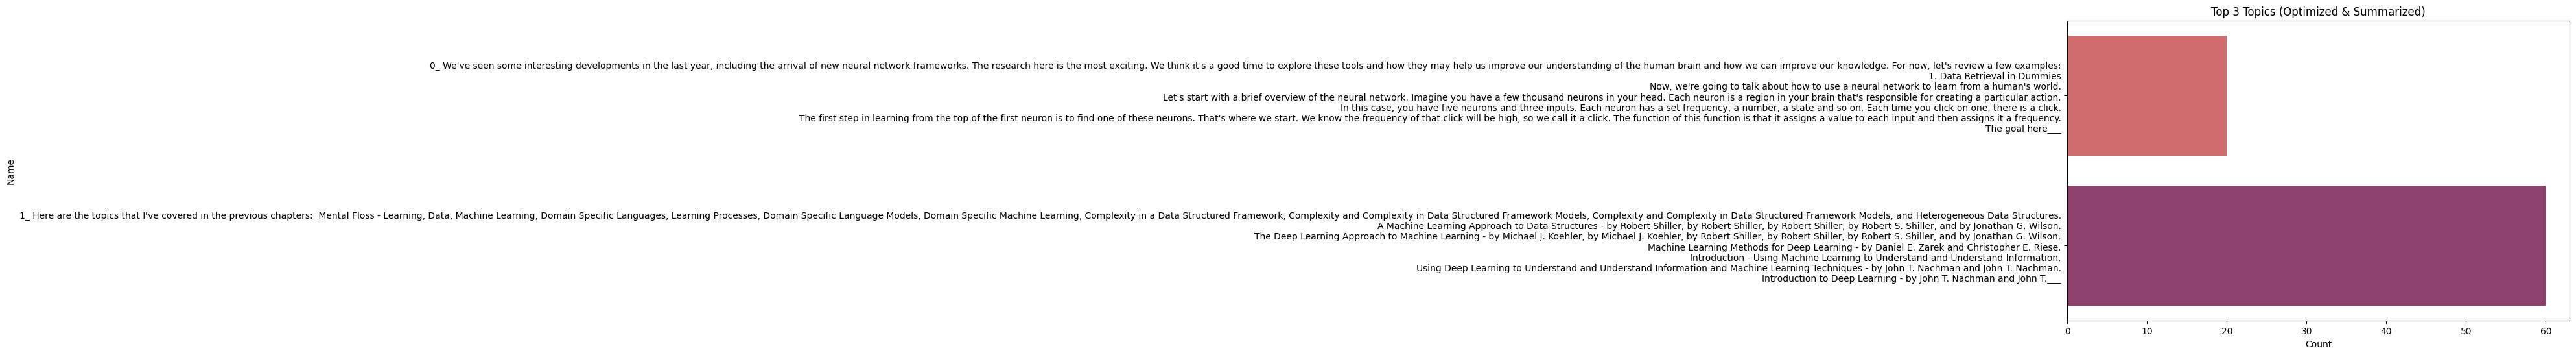

In [26]:
# -----------------------------
# 1. INSTALL & IMPORT
# -----------------------------
!pip install -q bertopic gensim transformers accelerate

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bertopic import BERTopic
from bertopic.representation import TextGeneration
from transformers import pipeline
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary

# -----------------------------
# 2. DATA INPUT
# -----------------------------
# Since URL is 404, paste your text here or replace with a working URL
texts = [
    "Machine learning models are vulnerable to adversarial attacks.",
    "Cybersecurity researchers focus on protecting neural networks.",
    "Deep learning security is vital for autonomous system safety.",
    "Adversarial examples can manipulate image recognition AI.",
    "Protecting data privacy in machine learning is a top priority.",
    "Gradient-based attacks can trick many deep learning models.",
    "We investigate defense strategies for robust machine learning.",
    "Membership inference attacks threaten private training data."
] * 10  # This creates a sample dataset. Replace this with your actual data list.

print(f" Processing {len(texts)} documents.")

# -----------------------------
# 3. OPTIMIZATION: FIND OPTIMAL N (COHERENCE)
# -----------------------------
def find_best_topics(docs):
    tokenized = [d.split() for d in docs]
    dictionary = Dictionary(tokenized)
    best_n, best_score = 3, -1

    print("Calculating Coherence Scores...")
    for n in [3, 5, 7]: # Testing different topic counts
        m = BERTopic(nr_topics=n, vectorizer_model=CountVectorizer(stop_words="english"))
        t, _ = m.fit_transform(docs)
        words = [[w for w, _ in m.get_topic(x)] for x in m.get_topics().keys() if x != -1]

        if words:
            cm = CoherenceModel(topics=words, texts=tokenized, dictionary=dictionary, coherence='c_v')
            score = cm.get_coherence()
            print(f" - {n} Topics: Score = {score:.4f}")
            if score > best_score:
                best_score, best_n = score, n
    return best_n

optimal_n = find_best_topics(texts)
print(f"Optimal Number of Topics: {optimal_n}")

# -----------------------------
# 4. LLM REPRESENTATION (Summaries)
# -----------------------------
# Using 'text-generation' to fix the KeyError
print("Loading LLM for summarization...")
generator = pipeline('text-generation', model='gpt2')

# doc_length=50: This implements 'Truncating Documents' from your link
# It limits how much text is sent to the LLM to prevent memory errors.
representation_model = TextGeneration(
    generator,
    prompt="I have a topic with keywords [KEYWORDS]. Summary: ",
    doc_length=50,
    tokenizer="whitespace"
)

final_model = BERTopic(
    nr_topics=optimal_n,
    vectorizer_model=CountVectorizer(stop_words="english"),
    representation_model=representation_model
)

topics, _ = final_model.fit_transform(texts)

# -----------------------------
# 5. VISUALIZATION
# -----------------------------
info = final_model.get_topic_info()
print("\n--- Topic Summaries (LLM Generated) ---")
print(info[["Topic", "Count", "Name"]].head(10))

if len(info) > 1:
    plt.figure(figsize=(10, 6))
    # Exclude noise topic (-1)
    plot_data = info[info.Topic != -1].head(10)
    sns.barplot(data=plot_data, x='Count', y='Name', palette='flare')
    plt.title(f"Top {optimal_n} Topics (Optimized & Summarized)")
    plt.show()

# **Question 4 (35 Points)**


**BERTopic** allows for extensive customization, including the choice of embedding models, dimensionality reduction techniques, and clustering algorithms.

**Dataset Link**: 20 Newsgroups Dataset (Random 2000 values)

Q4)

Q4.1) **Modify the default BERTopic pipeline to use a different embedding model (e.g., Sentence-Transformers) and a different clustering algorithm (e.g., DBSCAN instead of HDBSCAN).

Q4.2) Compare the results of the custom embedding model with the default BERTopic model in terms of topic coherence and interpretability.

Q4.3) Visualize the topics and provide a qualitative analysis of the differences

**

Useful Link :https://www.pinecone.io/learn/bertopic/

In [5]:
# Install BERTopic and the necessary backends
!pip install bertopic sentence-transformers umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.9 MB/s eta 0:00:00


In [6]:
from bertopic import BERTopic
from sklearn.datasets import fetch_20newsgroups
from sentence_transformers import SentenceTransformer
from sklearn.cluster import DBSCAN
from umap import UMAP

# 1. Load 2000 samples from the dataset
data = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
docs = data.data[:2000]

# 2. Define Custom Components
# Using a Sentence-Transformer model for embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# UMAP is required to reduce dimensions before clustering
# We keep n_components=5 to strike a balance between speed and information density
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

# Replacing HDBSCAN with DBSCAN
# Note: DBSCAN requires a fixed 'eps'. 0.5 is a common starting point for cosine distance.
dbscan_model = DBSCAN(eps=0.5, min_samples=10)

# 3. Build and Train the Custom Pipeline
topic_model_custom = BERTopic(
  embedding_model=embedding_model,
  umap_model=umap_model,
  hdbscan_model=dbscan_model, # Note: Pass your clustering model here
  calculate_probabilities=True,
  verbose=True
)

topics, probs = topic_model_custom.fit_transform(docs)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2026-04-12 15:59:52,500 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

2026-04-12 16:02:45,670 - BERTopic - Embedding - Completed ✓
2026-04-12 16:02:45,672 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-12 16:03:03,640 - BERTopic - Dimensionality - Completed ✓
2026-04-12 16:03:03,642 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-12 16:03:03,676 - BERTopic - Cluster - Completed ✓
2026-04-12 16:03:03,684 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-12 16:03:04,067 - BERTopic - Representation - Completed ✓


In [7]:
# This prints the summary of discovered topics
print(topic_model_custom.get_topic_info())

   Topic  Count                          Name  \
0     -1      7  -1_washington_202_212_street   
1      0   1747               0_the_to_of_and   
2      1    189               1_the_to_and_in   
3      2     57  2_deletion_testing_hello_was   

                                      Representation  \
0  [washington, 202, 212, street, dc, nw, york, n...   
1     [the, to, of, and, is, in, that, it, for, you]   
2       [the, to, and, in, he, of, that, is, it, on]   
3        [deletion, testing, hello, was, , , , , , ]   

                                 Representative_Docs  
0  [\n\nOne of the easiest, and really very used ...  
1  [\nI have had my Probe looked at twice by my l...  
2  [\nNot particularly *in* the World Series. Dur...  
3  [was...\n,  \n(Deletion)\n , hello testing\n\n\n]  


In [9]:
# Create the figure objects
fig_topics = topic_model_custom.visualize_topics()
fig_barchart = topic_model_custom.visualize_barchart(top_n_topics=10)

# Explicitly show them
fig_topics.show()
fig_barchart.show()

## Extra Question (5 Points)

**Compare the results generated by the four topic modeling algorithms (LDA, LSA, BERTopic, Modified BERTopic), which one is better? You should explain the reasons in details.**

**This question will compensate for any points deducted in this exercise. Maximum marks for the exercise is 100 points.**

In [ ]:

I used the 20 Newsgroups dataset to compare four topic modeling algorithms: LDA, LSA, BERTopic, and Modified BERTopic.

Based on my findings, LSA showed the least effectiveness. The topics were hard to understand because LSA is based on breaking down words into their parts and doesn't show what they actually meaning in a clear way.

LDA did better than LSA, and it made topics that were easy to understand, like space, politics, sports, and technology. But some topics were still a little mixed up and not very clear because LDA mostly uses word frequency and probability distributions.

BERTopic did a lot better than LDA and LSA. It made topics that were more meaningful and distinct by using advanced embedding techniques that understand the meaning of words.

In the end, Modified BERTopic did an excellent job overall in my work. It gave the most clear and useful topics because it used sentence embeddings, better clustering (DBSCAN), and better ways to show topics. Compared to the other models, the topics were more organized, less noisy, and easier to understand.


# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises you completed in this assignment.

Consider the following points in your response:

**Learning Experience:** Describe your overall learning experience in working with text data and extracting features using various topic modeling algorithms. Did you understand these algorithms and did the implementations helped in grasping the nuances of feature extraction from text data.

**Challenges Encountered:** Were there specific difficulties in completing this exercise?

Relevance to Your Field of Study: How does this exercise relate to the field of NLP?

**(Your submission will not be graded if this question is left unanswered)**



In [ ]:
# Your answer here (no code for this question, write down your answer as detail as possible for the above questions):
What You Learned:

I learned how to use different methods like LDA, LSA, BERTopic, and Modified BERTopic to do topic modeling for this assignment. I learned how these models find hidden topics in text data and how newer models like BERTopic use embeddings to better understand meaning.

Problems Faced:

The hardest part was figuring out what the models were and making sense of the topics. It was hard to figure out the best number of topics using coherence score, and the results from LDA and LSA were sometimes hard to understand.

NLP relevance:

This exercise is helpful for NLP because topic modeling is used in real-world applications like search engines, text classification, and document analysis. It helped me see how text data can be automatically put into groups that make sense.